# Lecture 22: Artificial Neural Networks (ANN)

**F&W ECOL 458 — Environmental Data Science**

Reference: [scikit-learn Neural Network documentation](https://scikit-learn.org/stable/modules/neural_networks_supervised.html) | [TensorFlow/Keras](https://www.tensorflow.org/guide/keras)

---

### Learning objectives

1. Explain the biological inspiration behind artificial neural networks.
2. Describe the structure of a neuron, a layer, and a feedforward network.
3. Define activation functions and explain why nonlinear activations are essential.
4. Explain forward propagation and backpropagation at a conceptual level.
5. Train a simple ANN in `scikit-learn` and Keras for classification and regression.
6. Recognize overfitting in neural networks and apply regularization techniques.


## 1. Why Neural Networks?

We've now covered a powerful toolkit of ML algorithms: logistic regression, SVM, Naive Bayes, KNN, decision trees, random forests, and XGBoost. Why do we need another one?

Every algorithm we've seen has a fundamental limitation:

| Algorithm | What it can't do well |
|---|---|
| Linear models | Can't learn nonlinear patterns without manual feature engineering |
| SVM (RBF) | Slow on large datasets; kernel choice is manual |
| Tree ensembles | Struggle with smooth, continuous functions; can't process raw images or sequences |
| KNN | Slow at prediction; fails in high dimensions |

**Neural networks** are different. Given enough neurons and data, they can **learn any function** — including highly nonlinear, high-dimensional mappings that would be impossible to hand-engineer. This property is called the **universal approximation theorem**.

More importantly, neural networks are the foundation of **deep learning**, which has revolutionized:
- Image classification (identifying species from camera trap photos)
- Remote sensing (semantic segmentation of satellite imagery)
- Natural language processing (the technology behind ChatGPT)
- Time-series forecasting (predicting ecosystem fluxes)

Today we'll build the foundation. Next lecture, we'll go deeper.


## 2. The Biological Inspiration

### Real neurons

Your brain contains ~86 billion neurons. Each neuron:

1. **Receives signals** from other neurons through **dendrites**.
2. **Processes** those signals in the **cell body** — if the combined input exceeds a threshold, the neuron "fires."
3. **Sends the output** through an **axon** to other neurons via **synapses**.

The strength of each synapse determines how much influence one neuron has on another. Learning happens by adjusting these synaptic strengths.

### Artificial neurons

An artificial neuron mimics this process:

1. **Receives inputs** $x_1, x_2, \ldots, x_M$ (the features).
2. **Computes a weighted sum** $z = w_1 x_1 + w_2 x_2 + \ldots + w_M x_M + b$ (the weights are like synaptic strengths; $b$ is a bias term).
3. **Applies an activation function** $a = f(z)$ (this is the "fire or not" decision).
4. **Outputs** the result $a$ to the next layer.

Does this look familiar? It should — **a single artificial neuron with a sigmoid activation is exactly logistic regression!** Neural networks generalize logistic regression by stacking many neurons into layers.


<>:23: SyntaxWarning: invalid escape sequence '\S'
<>:23: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_4251/3137039862.py:23: SyntaxWarning: invalid escape sequence '\S'
  ax.text(5, 3.15, '$\Sigma$', ha='center', va='center', fontsize=16, fontweight='bold')


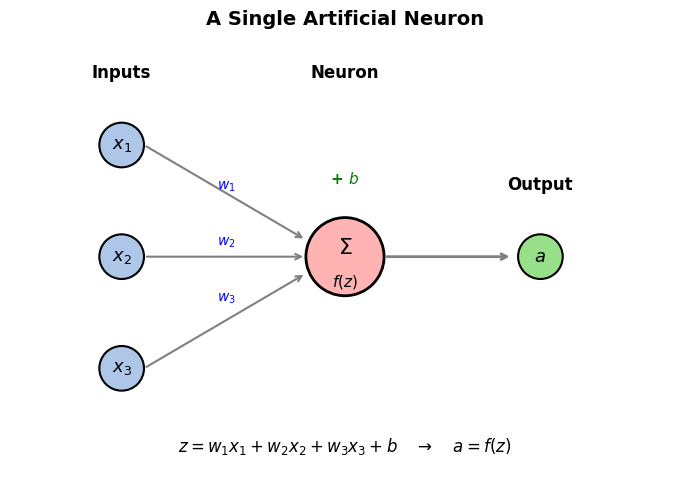

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Visualize a single artificial neuron ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('A Single Artificial Neuron', fontsize=14, fontweight='bold')

# Input nodes
input_labels = ['$x_1$', '$x_2$', '$x_3$']
input_y = [5, 3, 1]
for i, (label, y) in enumerate(zip(input_labels, input_y)):
    circle = plt.Circle((1, y), 0.4, color='#AEC7E8', ec='k', lw=1.5, zorder=3)
    ax.add_patch(circle)
    ax.text(1, y, label, ha='center', va='center', fontsize=13)

# Neuron body
circle_neuron = plt.Circle((5, 3), 0.7, color='#FFB3B3', ec='k', lw=2, zorder=3)
ax.add_patch(circle_neuron)
ax.text(5, 3.15, '$\Sigma$', ha='center', va='center', fontsize=16, fontweight='bold')
ax.text(5, 2.55, '$f(z)$', ha='center', va='center', fontsize=11)

# Connections with weight labels
for i, (y, w) in enumerate(zip(input_y, ['$w_1$', '$w_2$', '$w_3$'])):
    ax.annotate('', xy=(4.3, 3 + (y-3)*0.15), xytext=(1.4, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    mid_x = 2.7
    mid_y = (y + 3) / 2 + 0.2
    ax.text(mid_x, mid_y, w, fontsize=10, color='blue', fontweight='bold')

# Bias
ax.text(5, 4.3, '+ $b$', ha='center', fontsize=11, color='green', fontweight='bold')

# Output
ax.annotate('', xy=(8, 3), xytext=(5.7, 3),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
circle_out = plt.Circle((8.5, 3), 0.4, color='#98DF8A', ec='k', lw=1.5, zorder=3)
ax.add_patch(circle_out)
ax.text(8.5, 3, '$a$', ha='center', va='center', fontsize=13)

# Labels
ax.text(1, 6.2, 'Inputs', ha='center', fontsize=12, fontweight='bold')
ax.text(5, 6.2, 'Neuron', ha='center', fontsize=12, fontweight='bold')
ax.text(8.5, 4.2, 'Output', ha='center', fontsize=12, fontweight='bold')

# Formula
ax.text(5, -0.5, '$z = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$    →    $a = f(z)$',
        ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()


## 3. Activation Functions: The Nonlinear Magic

The activation function $f(z)$ is what gives neural networks their power. Without it, stacking layers of neurons would just produce another linear function — no matter how many layers, the result would be equivalent to a single logistic regression.

### Common activation functions

| Function | Formula | Range | When to use |
|---|---|---|---|
| **Sigmoid** | $\frac{1}{1+e^{-z}}$ | $(0, 1)$ | Output layer for binary classification |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1, 1)$ | Hidden layers (centered at 0) |
| **ReLU** | $\max(0, z)$ | $[0, \infty)$ | Default for hidden layers in modern networks |
| **Softmax** | $\frac{e^{z_i}}{\sum_j e^{z_j}}$ | $(0, 1)$, sums to 1 | Output layer for multi-class classification |

**ReLU** (Rectified Linear Unit) is the most widely used activation in practice because it's simple, fast to compute, and avoids the "vanishing gradient" problem that plagues sigmoid and tanh in deep networks.


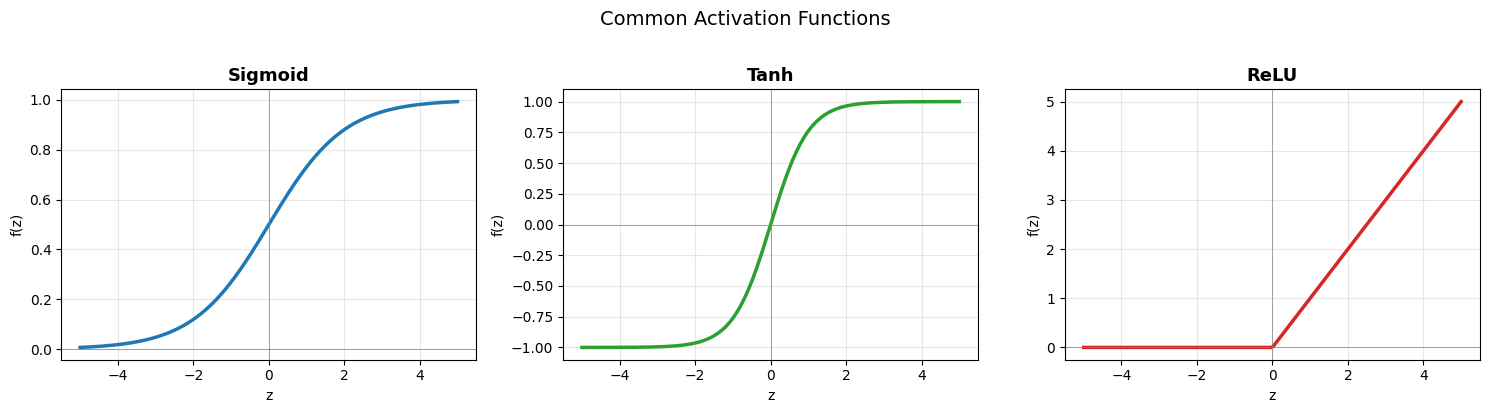

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 200)

sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Sigmoid', 'Tanh', 'ReLU']
funcs = [sigmoid, tanh, relu]
colors = ['#1f77b4', '#2ca02c', '#d62728']

for ax, title, f, color in zip(axes, titles, funcs, colors):
    ax.plot(z, f, color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Common Activation Functions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Why nonlinearity matters

Consider trying to classify land cover from spectral data. The relationship between "NDVI" and "forest probability" isn't linear — it's more like a step function: below ~0.3, it's almost certainly not forest; above ~0.5, it almost certainly is; in between, it's uncertain. The activation function lets the network capture this kind of threshold behavior.

Without activation functions, a 100-layer neural network would collapse to a single linear equation. **The activation functions are what make stacking layers meaningful.**


## 4. Network Architecture: Layers and Depth

A neural network is built by organizing neurons into **layers**:

### Feedforward network structure

```
Input Layer → Hidden Layer(s) → Output Layer
```

- **Input layer:** One neuron per feature. For 6 Landsat bands, the input layer has 6 neurons. No computation happens here — it just passes the data forward.
- **Hidden layer(s):** Where the learning happens. Each neuron in a hidden layer receives all outputs from the previous layer, computes a weighted sum, applies an activation, and passes the result forward. You choose the number of hidden layers and the number of neurons per layer.
- **Output layer:** Produces the final prediction. For binary classification, 1 neuron with sigmoid. For multi-class ($C$ classes), $C$ neurons with softmax. For regression, 1 neuron with no activation (linear output).

### How many layers and neurons?

| Architecture | Name | Capability |
|---|---|---|
| 0 hidden layers | Logistic regression | Linear boundaries only |
| 1 hidden layer | Shallow network | Can approximate any continuous function (universal approximation theorem) |
| 2+ hidden layers | Deep network | Can learn hierarchical features and complex abstractions |


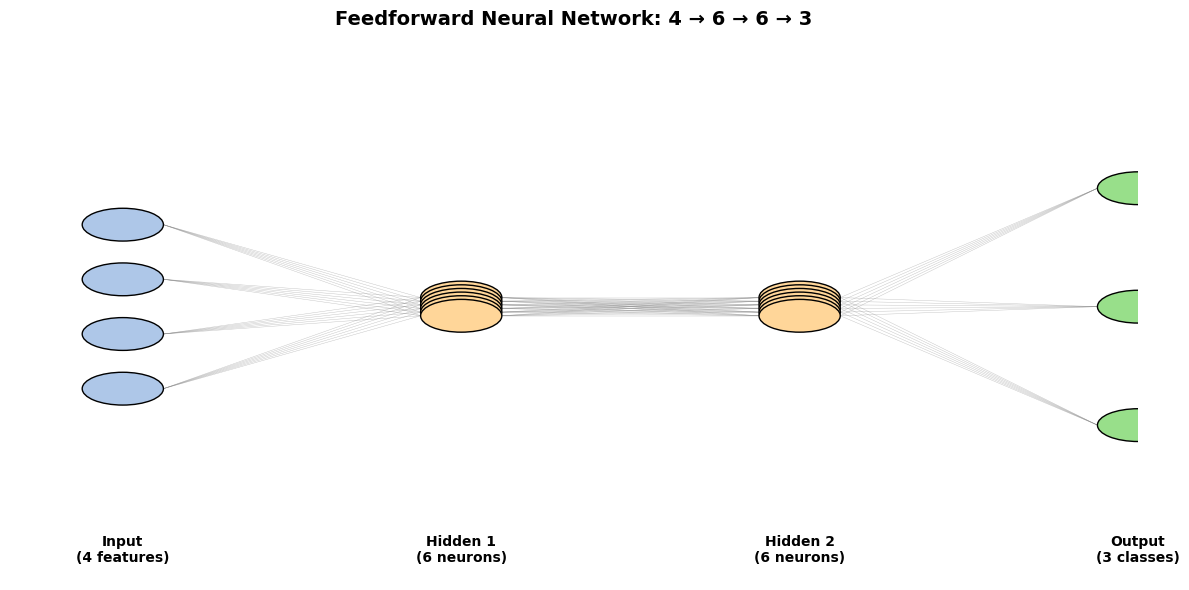

In [ ]:
# ── Visualize a simple feedforward network ──
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 5.5)
ax.axis('off')

layer_sizes = [4, 6, 6, 3]
layer_names = ['Input\n(4 features)', 'Hidden 1\n(6 neurons)', 'Hidden 2\n(6 neurons)', 'Output\n(3 classes)']
layer_colors = ['#AEC7E8', '#FFD699', '#FFD699', '#98DF8A']
x_positions = [0, 1.5, 3.0, 4.5]

neuron_positions = {}
for layer_idx, (n, x, color) in enumerate(zip(layer_sizes, x_positions, layer_colors)):
    y_start = 2.5 - (n - 1) * 0.45 / 2 * (n / max(layer_sizes))
    positions = np.linspace(5 - n * 0.4, n * 0.4, n)
    for neuron_idx, y in enumerate(positions):
        circle = plt.Circle((x, y), 0.18, color=color, ec='k', lw=1, zorder=3)
        ax.add_patch(circle)
        neuron_positions[(layer_idx, neuron_idx)] = (x, y)

    ax.text(x, -0.3, layer_names[layer_idx], ha='center', fontsize=10, fontweight='bold')

# Draw connections between adjacent layers
for l in range(len(layer_sizes) - 1):
    for i in range(layer_sizes[l]):
        for j in range(layer_sizes[l + 1]):
            x1, y1 = neuron_positions[(l, i)]
            x2, y2 = neuron_positions[(l + 1, j)]
            ax.plot([x1 + 0.18, x2 - 0.18], [y1, y2], 'gray', lw=0.3, alpha=0.5)

ax.set_title('Feedforward Neural Network: 4 → 6 → 6 → 3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Forward Propagation: How the Network Makes Predictions

When you feed an input (e.g., a Landsat pixel with 6 band values) into the network, the computation flows **forward** through the layers:

1. The input values enter the input layer.
2. Each neuron in Hidden Layer 1 computes: $z = \mathbf{w} \cdot \mathbf{x} + b$, then $a = f(z)$.
3. The activations from Hidden Layer 1 become the inputs to Hidden Layer 2.
4. This continues until the output layer produces a prediction.

This process is called **forward propagation**. It's just a sequence of matrix multiplications and activation functions — fast to compute.

### A concrete example

Suppose we have a tiny network: 2 inputs → 2 hidden neurons (ReLU) → 1 output (sigmoid).

Input: $x_1 = 0.5$, $x_2 = 0.8$ (say, standardized NDVI and elevation).


In [ ]:
import numpy as np

# ── Manual forward propagation ──
# 2 inputs → 2 hidden neurons (ReLU) → 1 output (sigmoid)

# Input
x = np.array([0.5, 0.8])

# Weights and biases (normally learned; here set manually for illustration)
W1 = np.array([[0.4, -0.3],   # weights from inputs to hidden
               [0.2,  0.5]])
b1 = np.array([0.1, -0.1])

W2 = np.array([[0.7],         # weights from hidden to output
               [-0.4]])
b2 = np.array([0.2])

# ── Hidden layer ──
z1 = W1 @ x + b1        # weighted sum
a1 = np.maximum(0, z1)  # ReLU activation
print(f"Hidden layer:")
print(f"  z1 = W1 @ x + b1 = {z1}")
print(f"  a1 = ReLU(z1)    = {a1}")

# ── Output layer ──
z2 = W2.T @ a1 + b2     # weighted sum
a2 = 1 / (1 + np.exp(-z2))  # sigmoid activation
print(f"\nOutput layer:")
print(f"  z2 = W2.T @ a1 + b2 = {z2}")
print(f"  a2 = sigmoid(z2)    = {a2}")
print(f"\nPrediction: P(class 1) = {a2[0]:.3f}")
print(f"Classification: {'Class 1' if a2[0] >= 0.5 else 'Class 0'}")


Hidden layer:
  z1 = W1 @ x + b1 = [0.06 0.4 ]
  a1 = ReLU(z1)    = [0.06 0.4 ]

Output layer:
  z2 = W2.T @ a1 + b2 = [0.082]
  a2 = sigmoid(z2)    = [0.52048852]

Prediction: P(class 1) = 0.520
Classification: Class 1


That's the entire forward pass — just multiplications, additions, and activation functions. The network transforms the input through successive layers until it produces a prediction.

The question is: how do we find the right weights? That's where **backpropagation** comes in.


## 6. Training: Backpropagation and Gradient Descent

### The loss function

First, we need a way to measure how wrong the network's predictions are. For classification, we use **cross-entropy loss**:

$$
L = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]
$$

For regression, we use **mean squared error (MSE)** — same as linear regression.

### Backpropagation (conceptual)

Training a neural network means adjusting the weights to minimize the loss. The algorithm that does this is **backpropagation** combined with **gradient descent**:

1. **Forward pass:** Compute the prediction for a training example.
2. **Compute the loss:** How wrong is the prediction?
3. **Backward pass:** Compute the **gradient** of the loss with respect to every weight in the network. This uses the chain rule of calculus, propagating the error signal backward from the output layer to the input layer — hence "backpropagation."
4. **Update weights:** Adjust each weight in the direction that reduces the loss:

$$
w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{\partial L}{\partial w}
$$

where $\eta$ is the **learning rate** — a small step size.

5. **Repeat** for many iterations (**epochs**) over the entire training set.

### The kitchen analogy

Think of it this way: you're a chef trying to perfect a recipe. You taste the dish (forward pass), notice it's too salty (compute loss), trace the problem back to the salt step (backpropagation), and reduce the salt amount next time (weight update). After many iterations, the recipe converges to something delicious.

> **You don't need to implement backpropagation yourself.** Libraries like `scikit-learn`, TensorFlow, and PyTorch compute all gradients automatically. But understanding the concept helps you diagnose problems (e.g., learning rate too high = overshooting, too low = slow convergence).


## 7. ANN in `scikit-learn`

Let's train a neural network on the Iris dataset using `MLPClassifier` (Multi-Layer Perceptron).


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

iris = load_iris()
X, y = iris.data, iris.target

# ── IMPORTANT: Always scale features for neural networks ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

# ── Train a simple MLP ──
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),  # 2 hidden layers: 32 and 16 neurons
    activation='relu',            # ReLU activation
    max_iter=500,                 # Maximum training epochs
    random_state=42,
    learning_rate_init=0.001      # Learning rate
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print(f"Architecture: {mlp.hidden_layer_sizes}")
print(f"Number of iterations (epochs): {mlp.n_iter_}")
print(f"Final loss: {mlp.loss_:.4f}")
print(f"Test accuracy: {metrics.accuracy_score(y_test, y_pred):.2%}")
print(f"\nClassification report:")
print(metrics.classification_report(y_test, y_pred, target_names=iris.target_names))


Architecture: (32, 16)
Number of iterations (epochs): 423
Final loss: 0.0586
Test accuracy: 100.00%

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



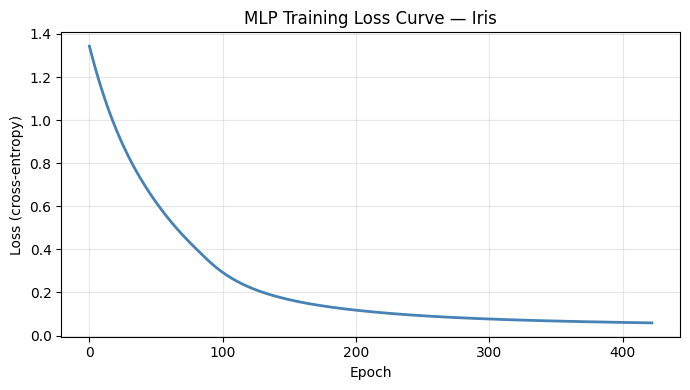

In [ ]:
# ── Training loss curve ──
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mlp.loss_curve_, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (cross-entropy)')
ax.set_title('MLP Training Loss Curve — Iris')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The loss curve shows the training error decreasing over epochs. The network is learning — each epoch adjusts the weights slightly to reduce the prediction error.

**Key things to notice:**
- We used `StandardScaler` — **neural networks are very sensitive to feature scaling** because the weight updates depend on gradient magnitudes, which are affected by input scales.
- The architecture `(32, 16)` means 2 hidden layers with 32 and 16 neurons respectively.
- ReLU activation is the default choice for hidden layers.
- The loss drops quickly in the first ~50 epochs, then plateaus — diminishing returns.


## 8. How Does the ANN Compare?


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X_sc = StandardScaler().fit_transform(iris.data)
y = iris.target

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM (RBF)":           SVC(kernel="rbf"),
    "Random Forest (100)":  RandomForestClassifier(100, random_state=42),
    "MLP (32, 16)":        MLPClassifier((32, 16), max_iter=500, random_state=42),
}

print(f"{'Classifier':<25s}  {'Mean CV accuracy':>16s}  {'Std':>6s}")
print("-" * 52)
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_sc, y, cv=5)
    print(f"{name:<25s}  {scores.mean():>15.3f}  {scores.std():>6.3f}")


Classifier                 Mean CV accuracy     Std
----------------------------------------------------
Logistic Regression                  0.960   0.039
SVM (RBF)                            0.967   0.021
Random Forest (100)                  0.967   0.021
MLP (32, 16)                         0.953   0.016


On the small, clean Iris dataset, the MLP performs comparably to the other methods. The real advantages of neural networks emerge with:
- **Large datasets** (thousands to millions of samples)
- **Complex patterns** (nonlinear interactions among many features)
- **Unstructured data** (images, text, time series — next lecture)

For tabular environmental data with fewer than ~10,000 samples, **random forests and XGBoost usually outperform neural networks** with less tuning effort. Neural networks shine when data is abundant and patterns are complex.


## 9. ANN for Regression

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Training R²: 0.640
Test R²:     0.462
Test RMSE:   55.1


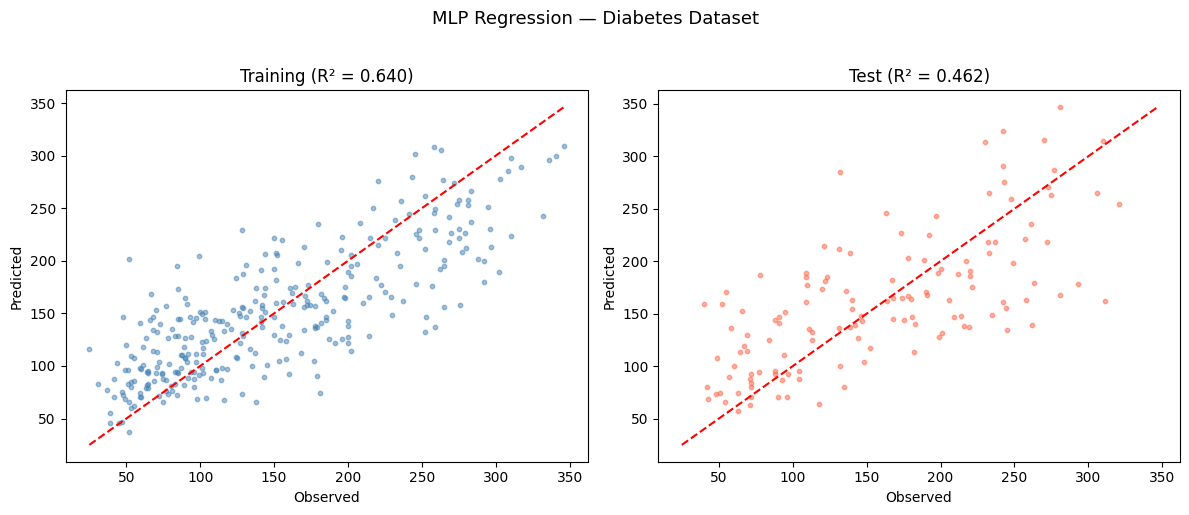

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt

# ── Using the diabetes dataset as a regression example ──
X, y = load_diabetes(return_X_y=True)

# Chronological-style split
train_len = int(0.7 * len(X))
X_train, X_test = X[:train_len], X[train_len:]
y_train, y_test = y[:train_len], y[train_len:]

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# ── Train MLP Regressor ──
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=1000,
    random_state=42,
    learning_rate_init=0.001
)
mlp_reg.fit(X_train_sc, y_train)

y_pred_train = mlp_reg.predict(X_train_sc)
y_pred_test = mlp_reg.predict(X_test_sc)

print(f"Training R²: {r2_score(y_train, y_pred_train):.3f}")
print(f"Test R²:     {r2_score(y_test, y_pred_test):.3f}")
print(f"Test RMSE:   {np.sqrt(mean_squared_error(y_test, y_pred_test)):.1f}")

# ── 1:1 plots ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, y_pred_train, s=10, alpha=0.5, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Training (R² = {r2_score(y_train, y_pred_train):.3f})')

axes[1].scatter(y_test, y_pred_test, s=10, alpha=0.5, color='tomato')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Test (R² = {r2_score(y_test, y_pred_test):.3f})')

plt.suptitle('MLP Regression — Diabetes Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Play ANN here:** https://playground.tensorflow.org/

## 10. Overfitting in Neural Networks

Neural networks have **many parameters** (each connection has a weight). A network with 2 hidden layers of 64 neurons each, processing 10 input features, has:

$10 \times 64 + 64 + 64 \times 64 + 64 + 64 \times 1 + 1 = 5,057$ parameters!

With so many parameters, overfitting is a serious risk — especially on small environmental datasets.

### Early Stopping, Regularization, and Learning Rate in ANN

When training an artificial neural network (ANN), the goal is not only to make it perform well on the training data, but also to make it work well on new unseen data. The following ideas are important for achieving that goal.

#### Early Stopping

Early stopping means we stop training before the model begins to overfit.

At the beginning of training, the model usually improves on both the training set and the validation set. However, if we keep training for too long, the model may start to memorize details and noise in the training data. When that happens, the training loss may continue to decrease, but the validation loss may stop improving or even begin to increase.

Early stopping uses the validation performance as a signal. We stop training when the validation loss has not improved for a while.

Intuitively, this is like studying for an exam. At first, more practice helps you understand the material better. But after a point, too much practice may lead to memorizing specific questions rather than learning the general ideas. Early stopping helps us stop at the point where learning is still useful.

#### Regularization

Regularization refers to methods that reduce overfitting and help the model generalize better.

A neural network with many parameters can become very flexible. That flexibility is powerful, but it also means the network may fit random noise in the training data. Regularization adds constraints so that the model learns simpler and more robust patterns.

Some common forms of regularization are:

- **L2 regularization (weight decay):** adds a penalty for very large weights, encouraging the model to use smaller and smoother parameter values.
- **L1 regularization:** adds a penalty based on the absolute value of the weights, which can push some weights toward zero.
- **Dropout:** randomly turns off some neurons during training so the network does not rely too heavily on any single pathway.
- **Data augmentation:** modifies training examples slightly, such as flipping or rotating images, so the model learns more general patterns instead of memorizing exact examples.

Intuitively, regularization is like telling the model: do not just find any solution that fits the training data; find a solution that is simpler, more stable, and more likely to work on new data.

#### Learning Rate

The learning rate controls how big a step the model takes when updating its weights during training.

Training a neural network usually involves gradient descent or one of its variants. In each step, the model adjusts its weights in the direction that reduces the loss. The learning rate determines how large that adjustment is.

- If the learning rate is **too large**, the model may jump around too much and fail to settle into a good solution.
- If the learning rate is **too small**, training becomes very slow and may take a long time to improve.

A good learning rate allows training to be both stable and efficient.

Intuitively, imagine walking downhill in fog. If your steps are too large, you may overshoot the best path or keep stumbling from side to side. If your steps are too small, you move very slowly. The learning rate controls the step size.

#### How These Ideas Work Together

These three concepts play different but related roles in training:

- **Learning rate** controls how the model moves during optimization.
- **Regularization** controls how complex the learned solution becomes.
- **Early stopping** controls when to stop training.

Together, they help us train a model that learns meaningful patterns without becoming too specialized to the training data.

#### Practical Summary

In practice, a common ANN training strategy is:

1. Choose a reasonable learning rate.
2. Monitor validation performance during training.
3. Use regularization to reduce overfitting.
4. Save the model with the best validation performance.
5. Stop training when validation performance stops improving.

This combination is widely used because it usually leads to models that are both accurate and reliable.

### Regularization strategies

| Strategy | How it works | sklearn parameter |
|---|---|---|
| **Early stopping** | Stop training when validation loss stops improving | `early_stopping=True` |
| **L2 regularization** | Penalize large weights (same idea as ridge regression) | `alpha=0.001` (default 0.0001) |
| **Dropout** | Randomly "turn off" neurons during training to prevent co-adaptation | Not in sklearn; available in Keras |
| **Reduce network size** | Fewer neurons/layers = fewer parameters = less overfitting | `hidden_layer_sizes` |

For tabular environmental data, **early stopping + mild L2 regularization** is usually sufficient.


Epochs used (with early stopping): 57
Test accuracy: 84.21%


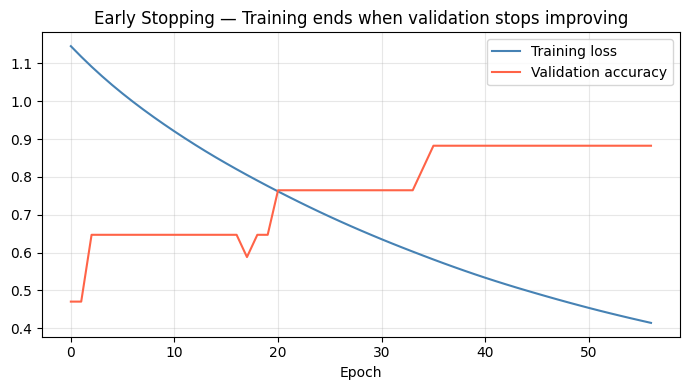

In [ ]:
# ── Early stopping demonstration ──
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

iris = load_iris()
X_sc = StandardScaler().fit_transform(iris.data)
X_train, X_test, y_train, y_test = train_test_split(X_sc, iris.target, test_size=0.25, random_state=42)

# With early stopping
mlp_es = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    early_stopping=True,          # ← Stop when validation loss plateaus
    validation_fraction=0.15,     # Use 15% of training data for validation
    n_iter_no_change=20,          # Stop if no improvement for 20 epochs
    random_state=42
)
mlp_es.fit(X_train, y_train)

print(f"Epochs used (with early stopping): {mlp_es.n_iter_}")
print(f"Test accuracy: {metrics.accuracy_score(y_test, mlp_es.predict(X_test)):.2%}")

# Plot training and validation loss
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mlp_es.loss_curve_, label='Training loss', color='steelblue')
ax.plot(mlp_es.validation_scores_, label='Validation accuracy', color='tomato')
ax.set_xlabel('Epoch')
ax.set_title('Early Stopping — Training ends when validation stops improving')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. When to Use Neural Networks

### Use ANNs when:
- You have a **large dataset** (thousands to millions of samples).
- The patterns are **highly nonlinear** and difficult for tree-based methods.
- You're working with **unstructured data** (images, text, sequences) — this requires deep learning (next lecture).
- You need a **continuous, differentiable model** (e.g., for physics-informed ML or coupling with process models).

### Prefer tree-based methods (RF/XGBoost) when:
- You have a **small to medium tabular dataset** (< 10,000 samples).
- You need **feature importance** rankings (ANNs don't provide this easily).
- You want **minimal preprocessing** (trees don't need scaling; ANNs do).
- You want **fast training with minimal hyperparameter tuning**.
- **Interpretability** is important.

### Practical summary for environmental data science

| Dataset size | Data type | Recommended |
|---|---|---|
| < 1,000 | Tabular | Random Forest or XGBoost |
| 1,000 – 100,000 | Tabular | Random Forest, XGBoost, or simple MLP |
| > 100,000 | Tabular | XGBoost or MLP |
| Any size | Images (satellite, camera traps) | Convolutional Neural Networks (CNN) — next lecture |
| Any size | Time series (flux data, phenology) | Recurrent networks (LSTM) or 1-D CNN |


## 12. Summary

| Concept | Key takeaway |
|---|---|
| Artificial neuron | Weighted sum of inputs → activation function → output |
| Activation functions | Sigmoid, Tanh, ReLU (most common), Softmax |
| Feedforward network | Input → Hidden layers → Output; information flows one direction |
| Forward propagation | Compute predictions by passing inputs through layers |
| Backpropagation | Compute gradients of loss w.r.t. weights; use chain rule to propagate errors backward |
| Gradient descent | Update weights in the direction that reduces loss |
| Feature scaling | **Mandatory** — use StandardScaler before training |
| Overfitting | Mitigate with early stopping, L2 regularization, dropout, smaller networks |
| When to use | Large datasets, complex patterns, unstructured data (images/text) |
| When NOT to use | Small tabular datasets — prefer Random Forest / XGBoost |

### Key hyperparameters

| Parameter | What it controls | Typical values |
|---|---|---|
| `hidden_layer_sizes` | Architecture (neurons per layer) | `(32,)`, `(64, 32)`, `(128, 64, 32)` |
| `activation` | Nonlinearity | `'relu'` (default and recommended) |
| `learning_rate_init` | Step size for weight updates | 0.001 (default), range 0.0001–0.01 |
| `max_iter` | Maximum epochs | 200–1000 |
| `alpha` | L2 regularization strength | 0.0001 (default), increase if overfitting |
| `early_stopping` | Stop when validation loss plateaus | `True` (recommended) |
